In [1]:
import main, torch, time, numpy as np, matplotlib.pyplot as plt
from utils.helper import plot_denoiser, eval_denoiser, plot_sample
from utils.dataset import DataSet
from models.unet import init_UNet
from models.unet_flex import load_learned_model
from inverse.sampler import sample_prior
from tqdm import tqdm
from utils.dataset import gamma_correct

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Sample from Denoiser Prior

UNet Trained on CelebA

In [2]:
model = init_UNet()

model_path = './assets/unet_celeba.pt'
model.load_state_dict(torch.load(model_path))
model = model.to(device).eval()

100%|███████████████████████████████████████████████████████████████████████████████████| 25/25 [00:05<00:00,  4.90it/s]


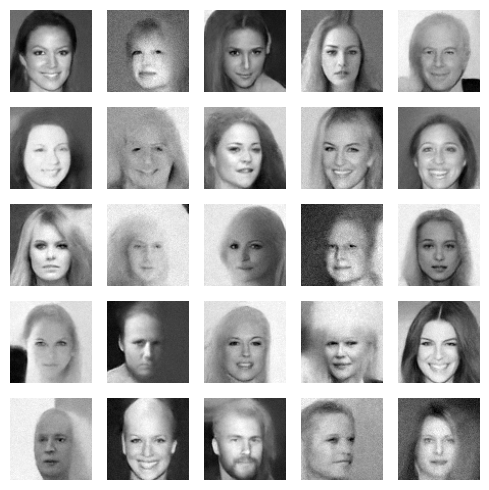

In [3]:
plot = plot_sample(model, n_sample=25, 
                   im_size=(1, 80, 80),
                   beta=0.10, h_init=0.05,
                   mu=0.20, fix_h=False)

plot.show()

### MNIST

In [4]:
model = init_UNet({'num_blocks':2})

model_path = './assets/unet_mnist.pt'
model.load_state_dict(torch.load(model_path))
model = model.to(device).eval()

100%|███████████████████████████████████████████████████████████████████████████████████| 25/25 [00:02<00:00,  9.68it/s]


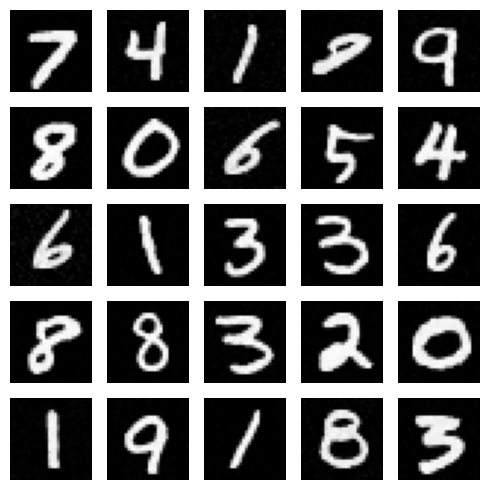

In [5]:
plot = plot_sample(model, n_sample=25, 
                   im_size=(1, 28, 28),
                   beta=0.10, h_init=0.10,
                   mu=0.25, fix_h=False)
plot.show()